In [1]:
# ============================================================
# OASIS INFOBYTE - DATA ANALYTICS TASK 7
# WINE QUALITY PREDICTION
# ============================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# ============================================================
# 2. LOAD WINE QUALITY DATASET
# ============================================================

print("Loading Wine Quality dataset...")

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"

df = pd.read_csv(
    url,
    sep=";"
)

print("\nDataset loaded successfully!")

print("Shape:", df.shape)

display(df.head())

Loading Wine Quality dataset...

Dataset loaded successfully!
Shape: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [3]:
# ============================================================
# 3. DATASET INSPECTION
# ============================================================

print("Dataset Information")
print("====================")

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
display(df.isnull().sum())

print("\nDescriptive Statistics:")
display(df.describe().T)

print("\nWine Quality Class Distribution:")
print(df["quality"].value_counts().sort_index())

Dataset Information

Rows: 1599
Columns: 12

Column Names:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']

Data Types:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Missing Values:


,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0



Descriptive Statistics:


,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000



Wine Quality Class Distribution:
quality
3     10
4     53
5    681
6    638
7    199
8     18
Name: count, dtype: int64


Wine Quality Distribution


,Number of Wines
quality,
3,10
4,53
5,681
6,638
7,199
8,18


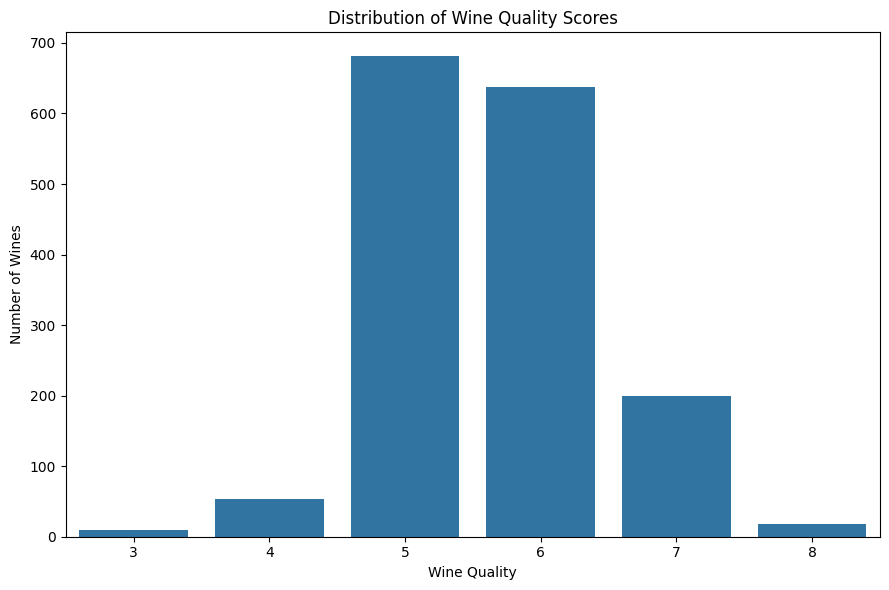


Chemical Feature Distributions


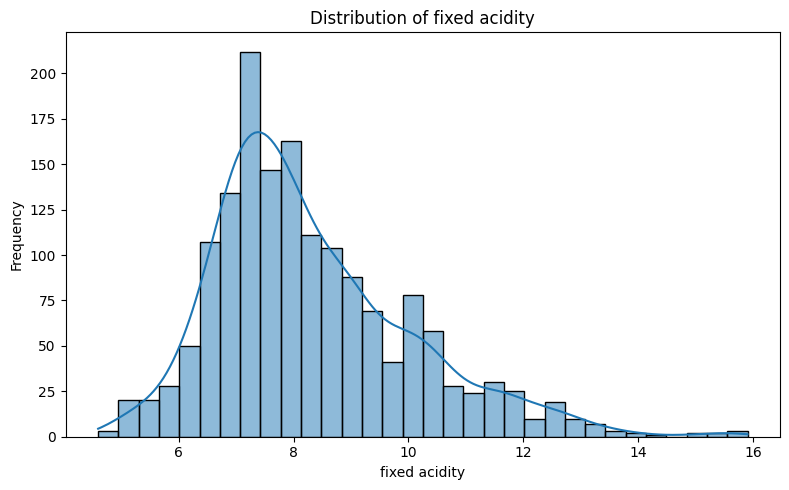

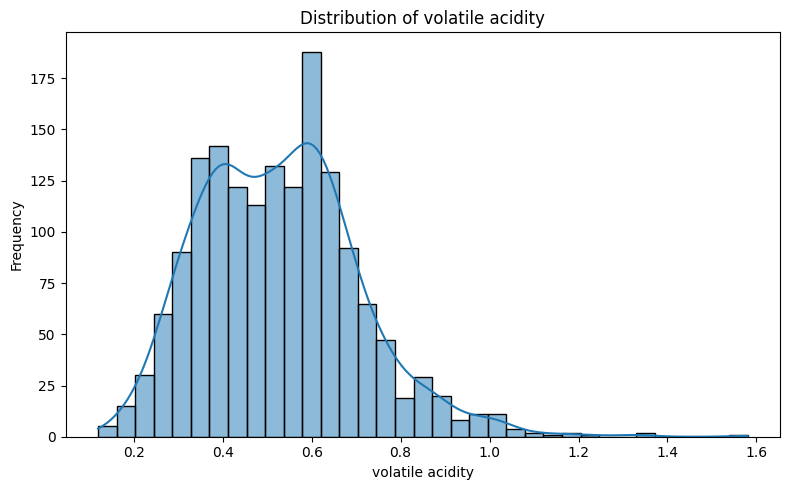

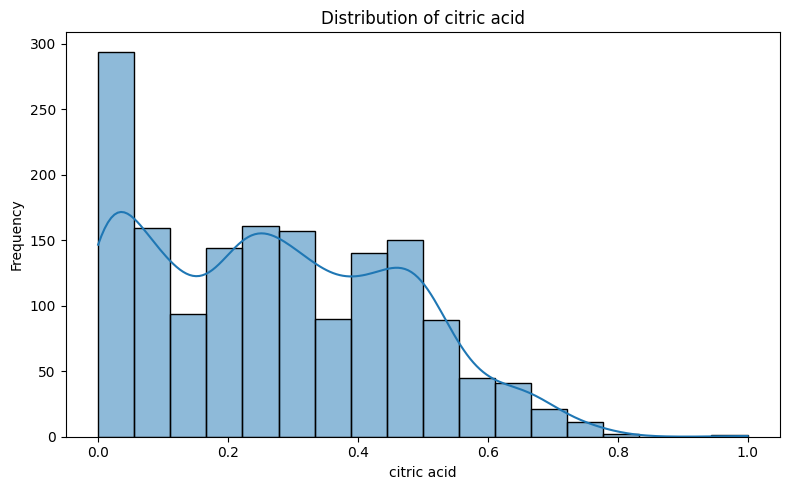

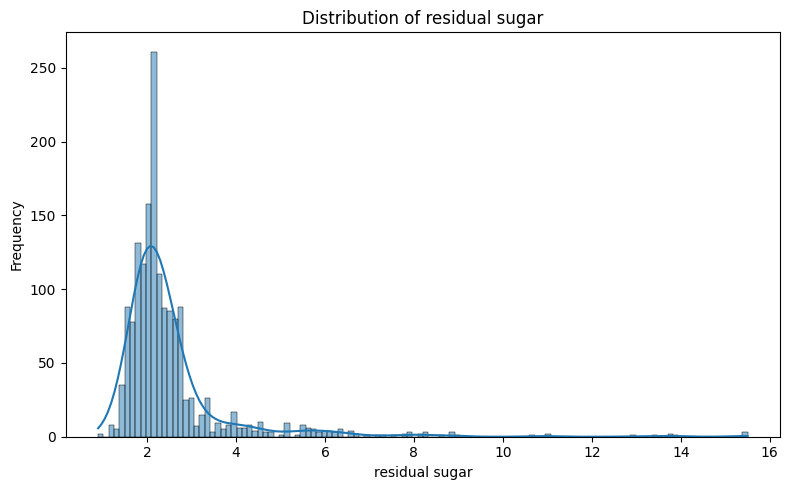

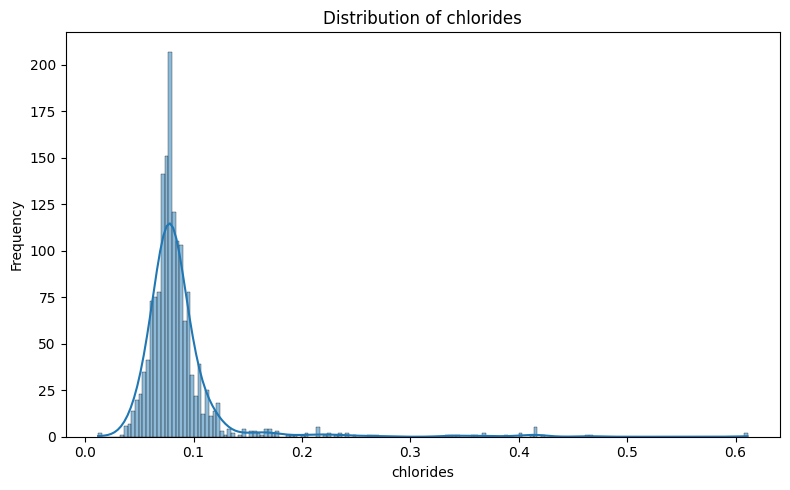

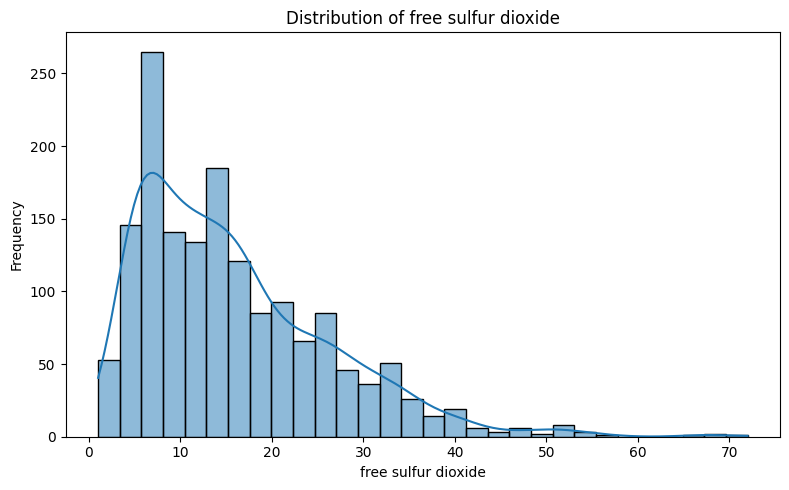

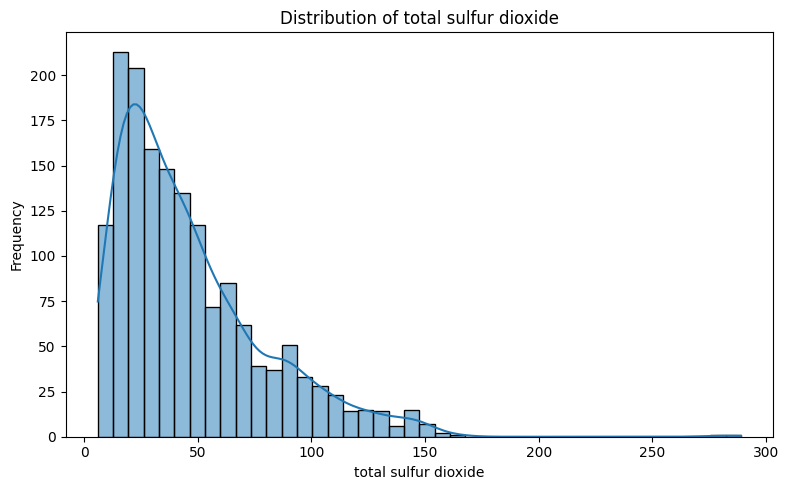

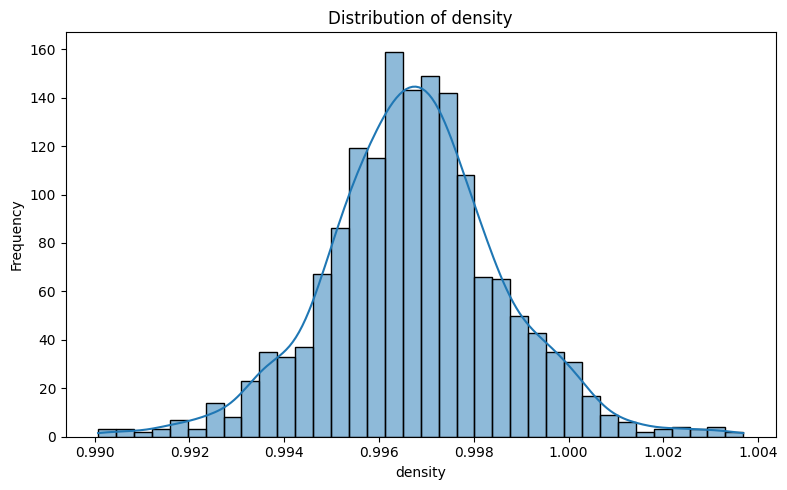

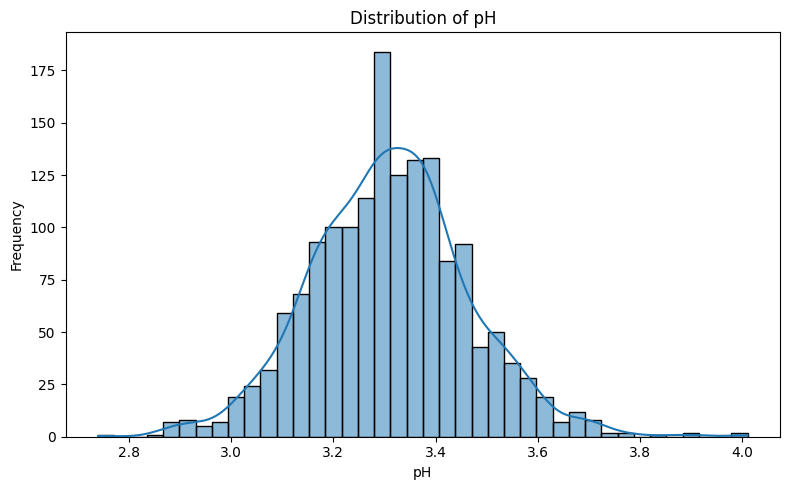

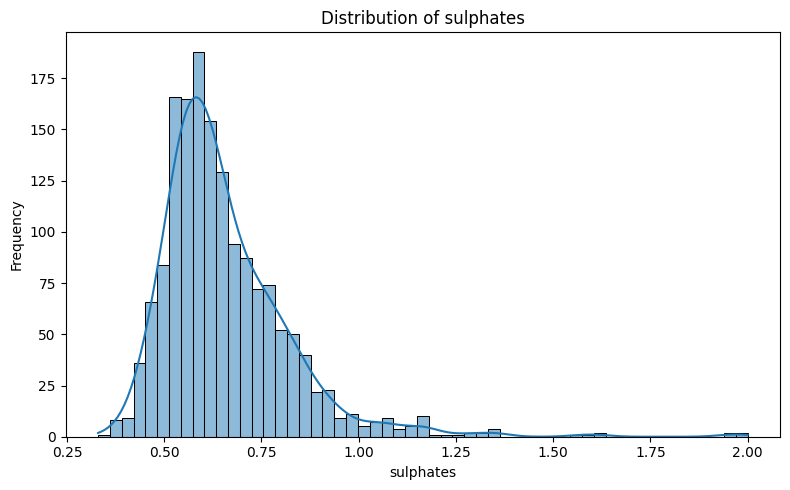

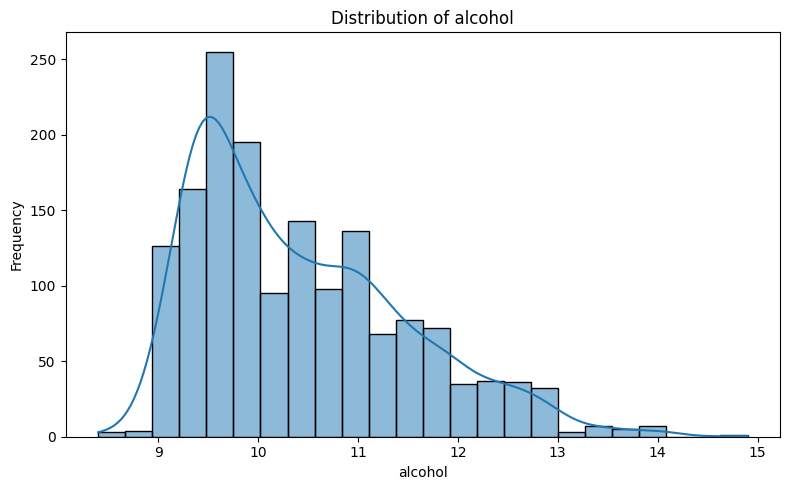


Correlation Heatmap


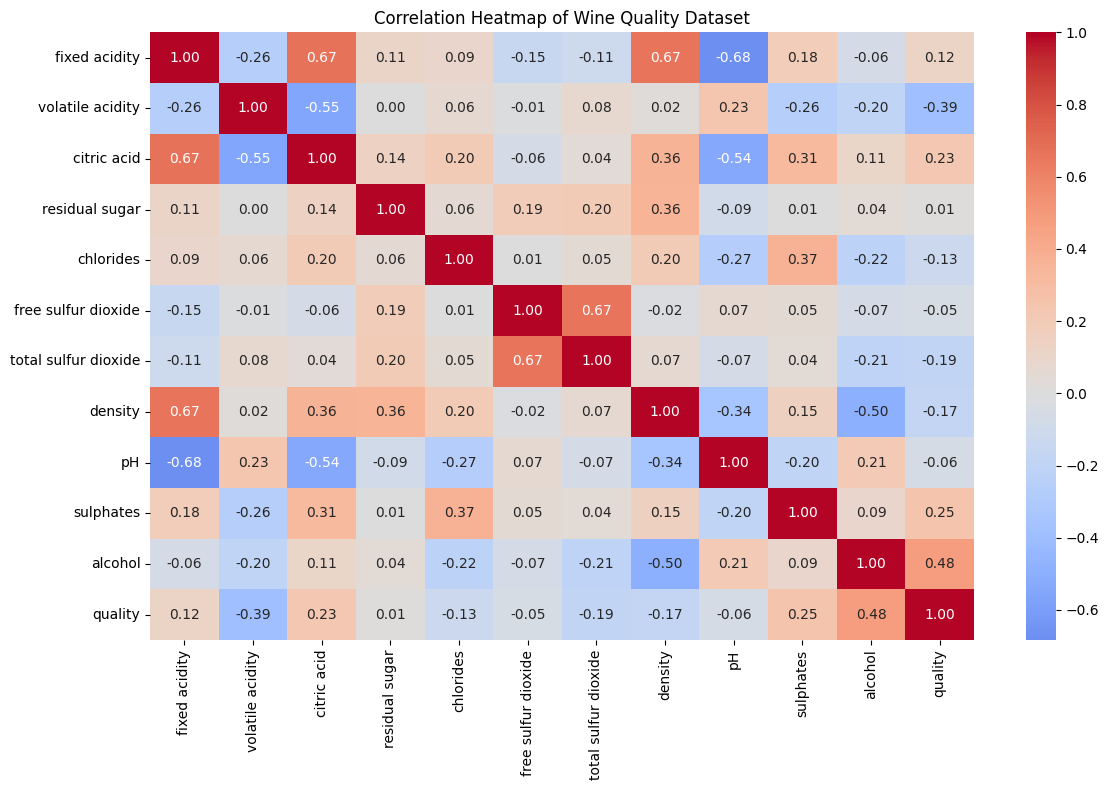


Correlation with Wine Quality


,Correlation with Quality
quality,1.000000
alcohol,0.476166
sulphates,0.251397
citric acid,0.226373
fixed acidity,0.124052
residual sugar,0.013732
free sulfur dioxide,-0.050656
pH,-0.057731
chlorides,-0.128907
density,-0.174919


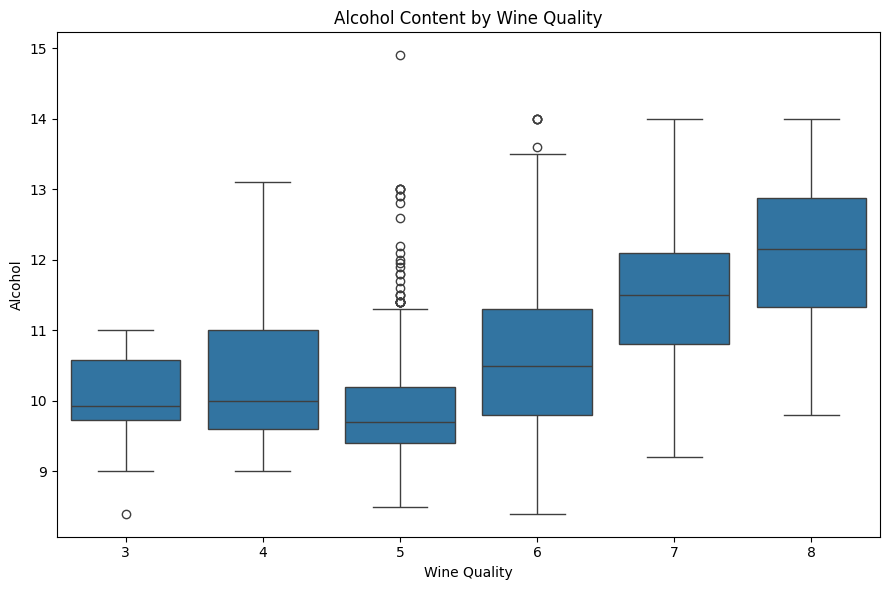

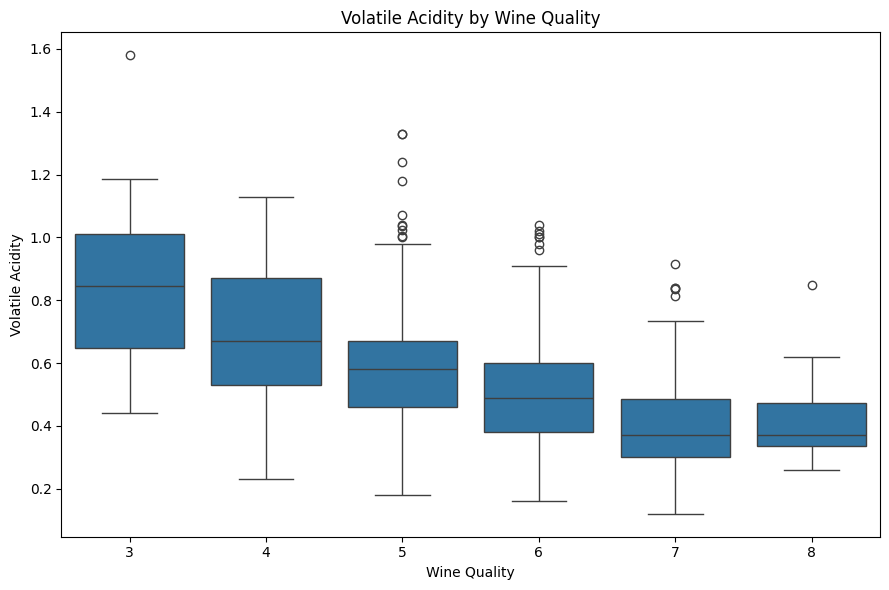


EDA completed successfully!


In [4]:
# ============================================================
# 4. EXPLORATORY DATA ANALYSIS
# ============================================================

# -----------------------------
# 4.1 CLASS DISTRIBUTION
# -----------------------------

print("Wine Quality Distribution")
print("=========================")

quality_counts = df["quality"].value_counts().sort_index()

display(
    quality_counts.to_frame("Number of Wines")
)

plt.figure(figsize=(9, 6))

sns.countplot(
    data=df,
    x="quality"
)

plt.title("Distribution of Wine Quality Scores")
plt.xlabel("Wine Quality")
plt.ylabel("Number of Wines")

plt.tight_layout()
plt.show()


# -----------------------------
# 4.2 CHEMICAL FEATURES
# -----------------------------

features = [
    "fixed acidity",
    "volatile acidity",
    "citric acid",
    "residual sugar",
    "chlorides",
    "free sulfur dioxide",
    "total sulfur dioxide",
    "density",
    "pH",
    "sulphates",
    "alcohol"
]

print("\nChemical Feature Distributions")
print("==============================")

for feature in features:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=feature,
        kde=True
    )

    plt.title(
        "Distribution of " + feature
    )

    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# -----------------------------
# 4.3 CORRELATION HEATMAP
# -----------------------------

print("\nCorrelation Heatmap")
print("===================")

plt.figure(figsize=(12, 8))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Correlation Heatmap of Wine Quality Dataset"
)

plt.tight_layout()
plt.show()


# -----------------------------
# 4.4 CORRELATION WITH QUALITY
# -----------------------------

print("\nCorrelation with Wine Quality")
print("=============================")

quality_correlation = (
    df.corr()["quality"]
    .sort_values(
        ascending=False
    )
)

display(
    quality_correlation.to_frame(
        "Correlation with Quality"
    )
)


# -----------------------------
# 4.5 QUALITY VS ALCOHOL
# -----------------------------

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="quality",
    y="alcohol"
)

plt.title(
    "Alcohol Content by Wine Quality"
)

plt.xlabel("Wine Quality")
plt.ylabel("Alcohol")

plt.tight_layout()
plt.show()


# -----------------------------
# 4.6 QUALITY VS VOLATILE ACIDITY
# -----------------------------

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df,
    x="quality",
    y="volatile acidity"
)

plt.title(
    "Volatile Acidity by Wine Quality"
)

plt.xlabel("Wine Quality")
plt.ylabel("Volatile Acidity")

plt.tight_layout()
plt.show()


print("\nEDA completed successfully!")

In [6]:
# ============================================================
# 5. DATA PREPARATION
# ============================================================

print("Preparing data for machine learning...")
print("=====================================")

# Separate features and target
X = df.drop(columns=["quality"])
y = df["quality"]

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("quality")

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)


# ============================================================
# 5.1 TRAIN / TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTrain/Test Split")
print("================")

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

print("\nTraining class distribution:")
print(y_train.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test.value_counts().sort_index())


# ============================================================
# 5.2 FEATURE SCALING
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("\nFeature scaling completed successfully!")


# ============================================================
# 5.3 CHECK SHAPES
# ============================================================

print("\nFinal Data Shapes")
print("=================")

print("X_train:", X_train_scaled.shape)
print("X_test :", X_test_scaled.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)


print("\nSTEP 5 COMPLETED SUCCESSFULLY!")

Preparing data for machine learning...

Features:
['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']

Target:
quality

Feature shape: (1599, 11)
Target shape: (1599,)

Train/Test Split
Training samples: 1279
Testing samples: 320

Training class distribution:
quality
3      8
4     42
5    545
6    510
7    159
8     15
Name: count, dtype: int64

Testing class distribution:
quality
3      2
4     11
5    136
6    128
7     40
8      3
Name: count, dtype: int64

Feature scaling completed successfully!

Final Data Shapes
X_train: (1279, 11)
X_test : (320, 11)
y_train: (1279,)
y_test : (320,)

STEP 5 COMPLETED SUCCESSFULLY!


In [7]:
# ============================================================
# 6. TRAIN THREE CLASSIFICATION MODELS
# ============================================================

print("Training classification models...")
print("================================")

# ============================================================
# 6.1 RANDOM FOREST
# ============================================================

print("\nTraining Random Forest...")

random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

random_forest.fit(
    X_train,
    y_train
)

rf_pred = random_forest.predict(
    X_test
)

print("Random Forest trained successfully!")


# ============================================================
# 6.2 STOCHASTIC GRADIENT DESCENT
# ============================================================

print("\nTraining SGD Classifier...")

sgd_model = SGDClassifier(
    max_iter=2000,
    random_state=42,
    class_weight="balanced"
)

sgd_model.fit(
    X_train_scaled,
    y_train
)

sgd_pred = sgd_model.predict(
    X_test_scaled
)

print("SGD Classifier trained successfully!")


# ============================================================
# 6.3 SUPPORT VECTOR CLASSIFIER
# ============================================================

print("\nTraining Support Vector Classifier...")

svc_model = SVC(
    kernel="rbf",
    C=1.0,
    random_state=42,
    class_weight="balanced"
)

svc_model.fit(
    X_train_scaled,
    y_train
)

svc_pred = svc_model.predict(
    X_test_scaled
)

print("SVC trained successfully!")


# ============================================================
# 6.4 MODEL TRAINING SUMMARY
# ============================================================

print("\n==============================================")
print("ALL THREE MODELS TRAINED SUCCESSFULLY!")
print("==============================================")

print("1. Random Forest")
print("2. SGD Classifier")
print("3. Support Vector Classifier")

Training classification models...

Training Random Forest...
Random Forest trained successfully!

Training SGD Classifier...
SGD Classifier trained successfully!

Training Support Vector Classifier...
SVC trained successfully!

ALL THREE MODELS TRAINED SUCCESSFULLY!
1. Random Forest
2. SGD Classifier
3. Support Vector Classifier


                 MODEL EVALUATION

ACCURACY SCORES
----------------------------
Random Forest Accuracy: 0.6656
SGD Accuracy: 0.3594
SVC Accuracy: 0.4594

RANDOM FOREST - CLASSIFICATION REPORT
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.00      0.00      0.00        11
           5       0.72      0.74      0.73       136
           6       0.62      0.73      0.67       128
           7       0.70      0.47      0.57        40
           8       0.50      0.33      0.40         3

    accuracy                           0.67       320
   macro avg       0.42      0.38      0.39       320
weighted avg       0.64      0.67      0.65       320


SGD CLASSIFIER - CLASSIFICATION REPORT
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.09      0.18      0.12        11
           5       0.61      0.40      0.49       136
        

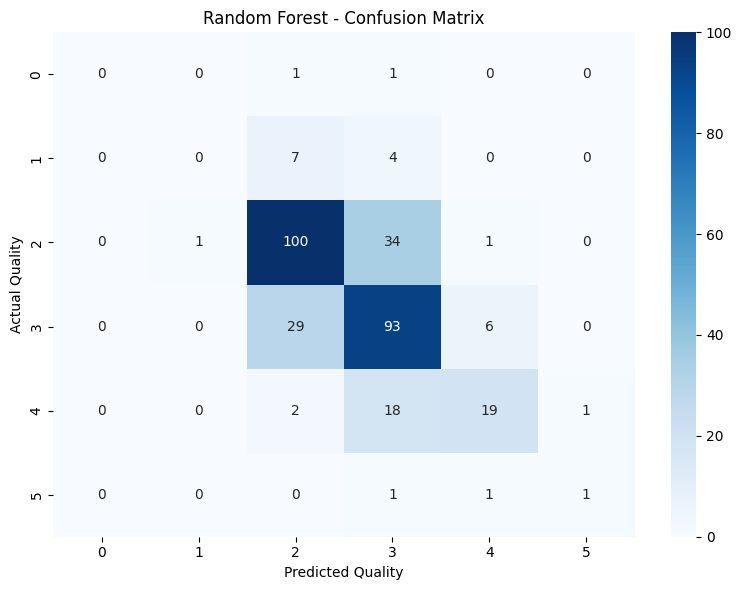

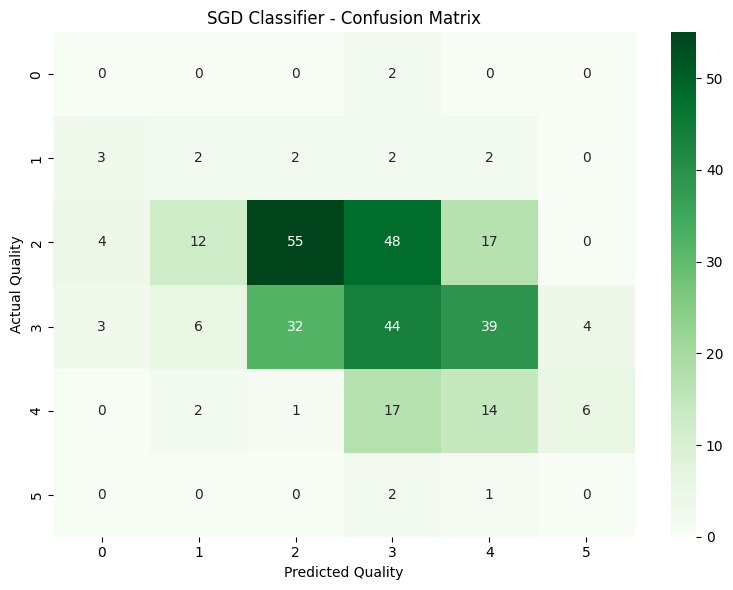

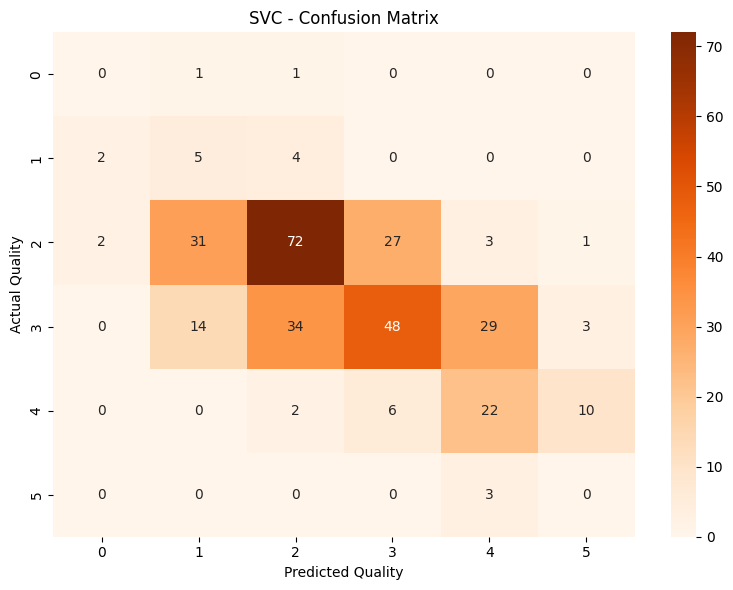


MODEL COMPARISON


,Model,Accuracy
0,Random Forest,0.665625
1,Support Vector Classifier,0.459375
2,SGD Classifier,0.359375


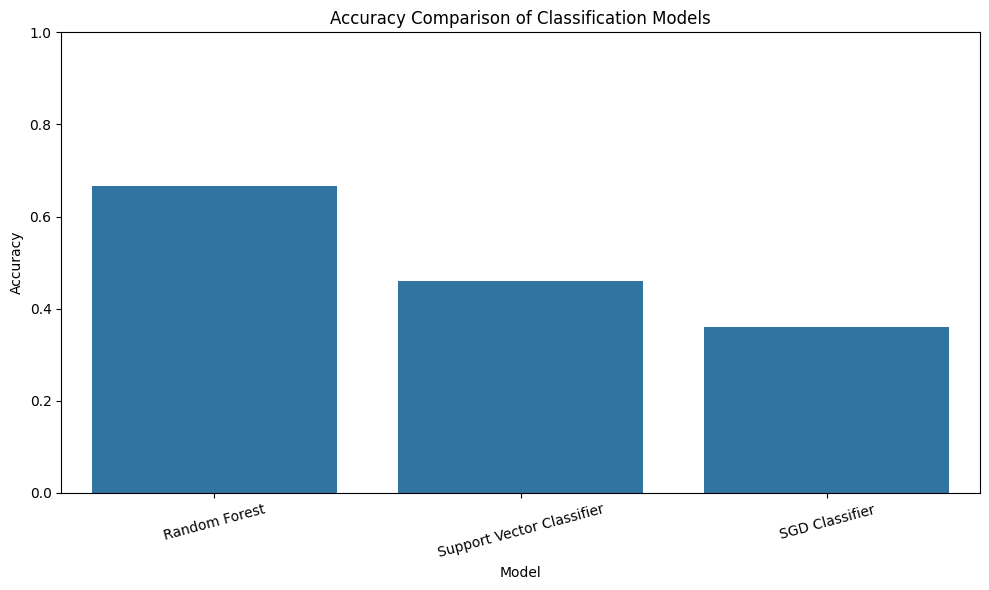


MODEL EVALUATION COMPLETED SUCCESSFULLY!


In [8]:
# ============================================================
# 7. MODEL EVALUATION
# ============================================================

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("============================================================")
print("                 MODEL EVALUATION")
print("============================================================")


# ============================================================
# 7.1 ACCURACY
# ============================================================

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

sgd_accuracy = accuracy_score(
    y_test,
    sgd_pred
)

svc_accuracy = accuracy_score(
    y_test,
    svc_pred
)

print("\nACCURACY SCORES")
print("----------------------------")

print(
    "Random Forest Accuracy:",
    round(rf_accuracy, 4)
)

print(
    "SGD Accuracy:",
    round(sgd_accuracy, 4)
)

print(
    "SVC Accuracy:",
    round(svc_accuracy, 4)
)


# ============================================================
# 7.2 RANDOM FOREST CLASSIFICATION REPORT
# ============================================================

print("\n============================================================")
print("RANDOM FOREST - CLASSIFICATION REPORT")
print("============================================================")

print(
    classification_report(
        y_test,
        rf_pred,
        zero_division=0
    )
)


# ============================================================
# 7.3 SGD CLASSIFICATION REPORT
# ============================================================

print("\n============================================================")
print("SGD CLASSIFIER - CLASSIFICATION REPORT")
print("============================================================")

print(
    classification_report(
        y_test,
        sgd_pred,
        zero_division=0
    )
)


# ============================================================
# 7.4 SVC CLASSIFICATION REPORT
# ============================================================

print("\n============================================================")
print("SUPPORT VECTOR CLASSIFIER - CLASSIFICATION REPORT")
print("============================================================")

print(
    classification_report(
        y_test,
        svc_pred,
        zero_division=0
    )
)


# ============================================================
# 7.5 CONFUSION MATRICES
# ============================================================

rf_cm = confusion_matrix(
    y_test,
    rf_pred
)

sgd_cm = confusion_matrix(
    y_test,
    sgd_pred
)

svc_cm = confusion_matrix(
    y_test,
    svc_pred
)


# ============================================================
# 7.6 RANDOM FOREST CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    "Random Forest - Confusion Matrix"
)

plt.xlabel(
    "Predicted Quality"
)

plt.ylabel(
    "Actual Quality"
)

plt.tight_layout()
plt.show()


# ============================================================
# 7.7 SGD CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    sgd_cm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title(
    "SGD Classifier - Confusion Matrix"
)

plt.xlabel(
    "Predicted Quality"
)

plt.ylabel(
    "Actual Quality"
)

plt.tight_layout()
plt.show()


# ============================================================
# 7.8 SVC CONFUSION MATRIX
# ============================================================

plt.figure(figsize=(8, 6))

sns.heatmap(
    svc_cm,
    annot=True,
    fmt="d",
    cmap="Oranges"
)

plt.title(
    "SVC - Confusion Matrix"
)

plt.xlabel(
    "Predicted Quality"
)

plt.ylabel(
    "Actual Quality"
)

plt.tight_layout()
plt.show()


# ============================================================
# 7.9 MODEL COMPARISON TABLE
# ============================================================

comparison = pd.DataFrame({

    "Model": [
        "Random Forest",
        "SGD Classifier",
        "Support Vector Classifier"
    ],

    "Accuracy": [
        rf_accuracy,
        sgd_accuracy,
        svc_accuracy
    ]

})

comparison = comparison.sort_values(
    by="Accuracy",
    ascending=False
).reset_index(
    drop=True
)

print("\n============================================================")
print("MODEL COMPARISON")
print("============================================================")

display(
    comparison
)


# ============================================================
# 7.10 ACCURACY COMPARISON GRAPH
# ============================================================

plt.figure(figsize=(10, 6))

sns.barplot(
    data=comparison,
    x="Model",
    y="Accuracy"
)

plt.title(
    "Accuracy Comparison of Classification Models"
)

plt.xlabel(
    "Model"
)

plt.ylabel(
    "Accuracy"
)

plt.ylim(
    0,
    1
)

plt.xticks(
    rotation=15
)

plt.tight_layout()
plt.show()


print("\n============================================================")
print("MODEL EVALUATION COMPLETED SUCCESSFULLY!")
print("============================================================")

          RANDOM FOREST FEATURE IMPORTANCE

Feature Importance:


,Feature,Importance
0,alcohol,0.143368
1,volatile acidity,0.133547
2,sulphates,0.122635
3,total sulfur dioxide,0.097197
4,density,0.088084
5,citric acid,0.077302
6,chlorides,0.077174
7,pH,0.072279
8,fixed acidity,0.065280
9,free sulfur dioxide,0.064002



Top 10 Important Features:


,Feature,Importance
0,alcohol,0.143368
1,volatile acidity,0.133547
2,sulphates,0.122635
3,total sulfur dioxide,0.097197
4,density,0.088084
5,citric acid,0.077302
6,chlorides,0.077174
7,pH,0.072279
8,fixed acidity,0.065280
9,free sulfur dioxide,0.064002


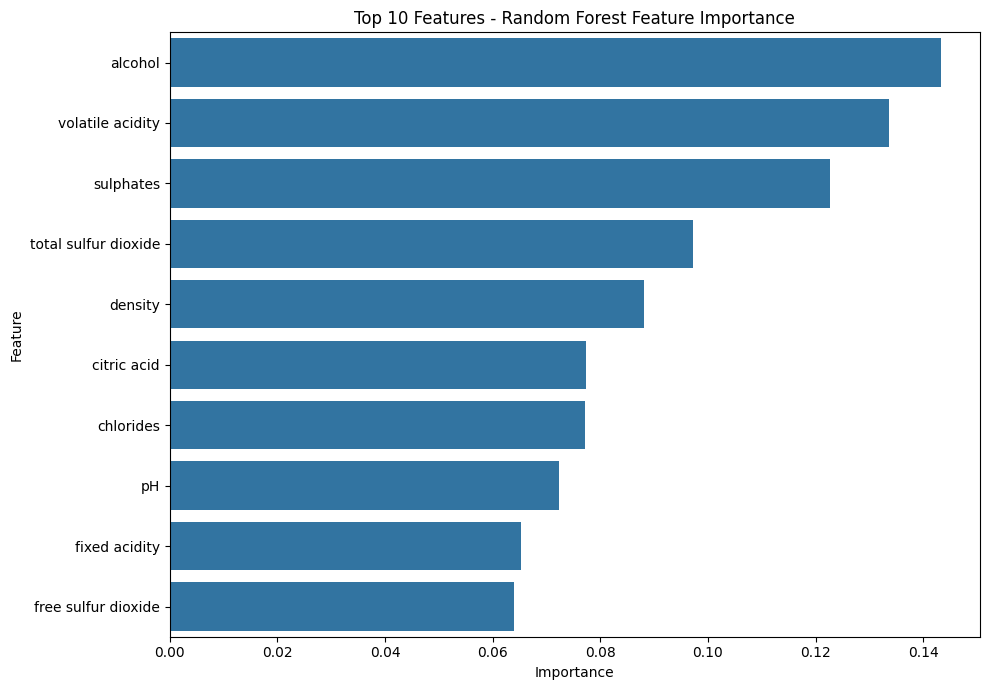


MOST IMPORTANT FEATURE
Feature: alcohol
Importance: 0.1434

FEATURE IMPORTANCE ANALYSIS COMPLETED!


In [9]:
# ============================================================
# 8. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

print("============================================================")
print("          RANDOM FOREST FEATURE IMPORTANCE")
print("============================================================")

# Get feature importance values
feature_importance = random_forest.feature_importances_

# Create feature importance DataFrame
importance_df = pd.DataFrame({

    "Feature": X.columns,

    "Importance": feature_importance

})

# Sort from highest to lowest
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)


# ============================================================
# 8.1 DISPLAY ALL FEATURE IMPORTANCE
# ============================================================

print("\nFeature Importance:")
print("===================")

display(
    importance_df
)


# ============================================================
# 8.2 TOP 10 IMPORTANT FEATURES
# ============================================================

top_features = importance_df.head(10)

print("\nTop 10 Important Features:")
print("==========================")

display(
    top_features
)


# ============================================================
# 8.3 FEATURE IMPORTANCE GRAPH
# ============================================================

plt.figure(
    figsize=(10, 7)
)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top 10 Features - Random Forest Feature Importance"
)

plt.xlabel(
    "Importance"
)

plt.ylabel(
    "Feature"
)

plt.tight_layout()

plt.show()


# ============================================================
# 8.4 MOST IMPORTANT FEATURE
# ============================================================

most_important_feature = importance_df.iloc[0]["Feature"]
highest_importance = importance_df.iloc[0]["Importance"]

print("\n============================================================")
print("MOST IMPORTANT FEATURE")
print("============================================================")

print(
    "Feature:",
    most_important_feature
)

print(
    "Importance:",
    round(highest_importance, 4)
)


print("\n============================================================")
print("FEATURE IMPORTANCE ANALYSIS COMPLETED!")
print("============================================================")

In [10]:
# ============================================================
# 9. FINAL ANALYSIS, CONCLUSION AND SAVE RESULTS
# ============================================================

print("============================================================")
print("              FINAL MODEL ANALYSIS")
print("============================================================")


# ============================================================
# 9.1 FIND BEST MODEL
# ============================================================

best_model = comparison.loc[
    comparison["Accuracy"].idxmax(),
    "Model"
]

best_accuracy = comparison["Accuracy"].max()


print("\nBest Performing Model:")
print("=====================")

print(
    "Model:",
    best_model
)

print(
    "Accuracy:",
    round(best_accuracy, 4)
)


# ============================================================
# 9.2 MODEL RANKING
# ============================================================

print("\nModel Ranking:")
print("==============")

for i, row in comparison.iterrows():

    print(
        f"{i + 1}. {row['Model']} "
        f"-> Accuracy: {row['Accuracy']:.4f}"
    )


# ============================================================
# 9.3 IMPORTANT FEATURES
# ============================================================

print("\nTop 5 Important Features:")
print("=========================")

display(
    importance_df.head(5)
)


# ============================================================
# 9.4 CREATE PREDICTION TABLE
# ============================================================

prediction_results = pd.DataFrame({

    "Actual Quality":
        y_test.values,

    "Random Forest Prediction":
        rf_pred,

    "SGD Prediction":
        sgd_pred,

    "SVC Prediction":
        svc_pred

})

print("\nPrediction Results:")
print("===================")

display(
    prediction_results.head(20)
)


# ============================================================
# 9.5 SAVE PREDICTIONS
# ============================================================

prediction_results.to_csv(
    "wine_quality_predictions.csv",
    index=False
)


# ============================================================
# 9.6 SAVE MODEL COMPARISON
# ============================================================

comparison.to_csv(
    "wine_quality_model_comparison.csv",
    index=False
)


# ============================================================
# 9.7 SAVE FEATURE IMPORTANCE
# ============================================================

importance_df.to_csv(
    "wine_quality_feature_importance.csv",
    index=False
)


# ============================================================
# 9.8 FINAL CONCLUSION
# ============================================================

print("\n============================================================")
print("                 TASK 7 CONCLUSION")
print("============================================================")

print(f"""
The Wine Quality dataset was analysed using
exploratory data analysis and classification techniques.

Three machine learning models were trained:

1. Random Forest
2. SGD Classifier
3. Support Vector Classifier

The models were evaluated using accuracy,
classification reports and confusion matrices.

The best performing model was:

{best_model}

with an accuracy of:

{best_accuracy:.4f}

Random Forest feature importance was also analysed
to identify the chemical properties that contributed
most to predicting wine quality.

The analysis shows that machine learning can be used
to classify wine quality based on physicochemical
properties such as acidity, alcohol, sulphates,
density and other chemical measurements.

Model performance can be improved further by using
hyperparameter tuning, advanced feature engineering,
and techniques for handling class imbalance.
""")


# ============================================================
# 9.9 SAVED FILES
# ============================================================

print("\n============================================================")
print("FILES SAVED SUCCESSFULLY")
print("============================================================")

print("1. wine_quality_predictions.csv")
print("2. wine_quality_model_comparison.csv")
print("3. wine_quality_feature_importance.csv")


# ============================================================
# 9.10 TASK COMPLETION MESSAGE
# ============================================================

print("\n============================================================")
print("       OASIS INFOBYTE DATA ANALYTICS TASK 7")
print("              COMPLETED SUCCESSFULLY!")
print("============================================================")

print("\nAll major Task 7 requirements have been completed:")
print("✓ Dataset loading")
print("✓ Data inspection")
print("✓ Class distribution analysis")
print("✓ Exploratory Data Analysis")
print("✓ Correlation heatmap")
print("✓ Train/Test split")
print("✓ Feature scaling")
print("✓ Random Forest")
print("✓ SGD Classifier")
print("✓ Support Vector Classifier")
print("✓ Accuracy evaluation")
print("✓ Classification reports")
print("✓ Confusion matrices")
print("✓ Model comparison")
print("✓ Random Forest feature importance")
print("✓ Final conclusion")
print("✓ Results saved")

              FINAL MODEL ANALYSIS

Best Performing Model:
Model: Random Forest
Accuracy: 0.6656

Model Ranking:
1. Random Forest -> Accuracy: 0.6656
2. Support Vector Classifier -> Accuracy: 0.4594
3. SGD Classifier -> Accuracy: 0.3594

Top 5 Important Features:


,Feature,Importance
0,alcohol,0.143368
1,volatile acidity,0.133547
2,sulphates,0.122635
3,total sulfur dioxide,0.097197
4,density,0.088084



Prediction Results:


,Actual Quality,Random Forest Prediction,SGD Prediction,SVC Prediction
0,6,6,6,7
1,5,6,6,6
2,5,5,6,5
3,5,6,6,6
4,6,6,7,5
5,6,6,5,7
6,5,5,5,5
7,4,5,3,4
8,6,5,5,5
9,8,8,6,7



                 TASK 7 CONCLUSION

The Wine Quality dataset was analysed using
exploratory data analysis and classification techniques.

Three machine learning models were trained:

1. Random Forest
2. SGD Classifier
3. Support Vector Classifier

The models were evaluated using accuracy,
classification reports and confusion matrices.

The best performing model was:

Random Forest

with an accuracy of:

0.6656

Random Forest feature importance was also analysed
to identify the chemical properties that contributed
most to predicting wine quality.

The analysis shows that machine learning can be used
to classify wine quality based on physicochemical
properties such as acidity, alcohol, sulphates,
density and other chemical measurements.

Model performance can be improved further by using
hyperparameter tuning, advanced feature engineering,
and techniques for handling class imbalance.


FILES SAVED SUCCESSFULLY
1. wine_quality_predictions.csv
2. wine_quality_model_comparison.csv
3. wine_